<a href="https://colab.research.google.com/github/Madhav-Sharma91/RFL-python-internship/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


DEPARTMENT AVERAGE PERFORMANCE
 Department
IT         94.857143
Finance    88.500000
Sales      82.400000
HR         76.250000
Name: Performance, dtype: float64

TOP 10 PERFORMERS
       Name Department  Performance
12   Arjun         IT           98
6    Rohan         IT           97
19   Tanya         IT           96
3    Sneha         IT           95
9     Isha         IT           94
15  Simran         IT           93
0    Aarav         IT           91
11   Meera    Finance           90
8    Karan    Finance           89
4   Vikram    Finance           88

ATTENDANCE BELOW 75%
       Name Department  Attendance
7     Neha         HR          71
13   Pooja         HR          74
18  Manish         HR          69


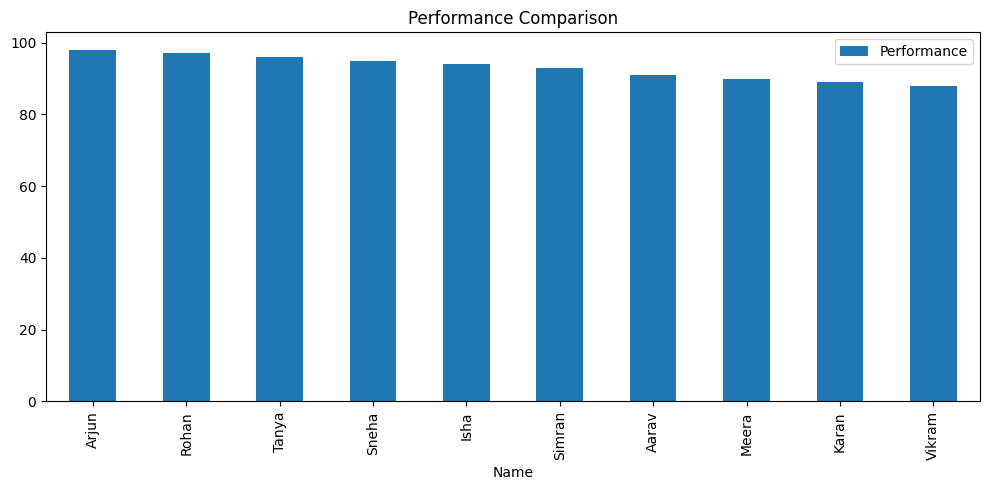

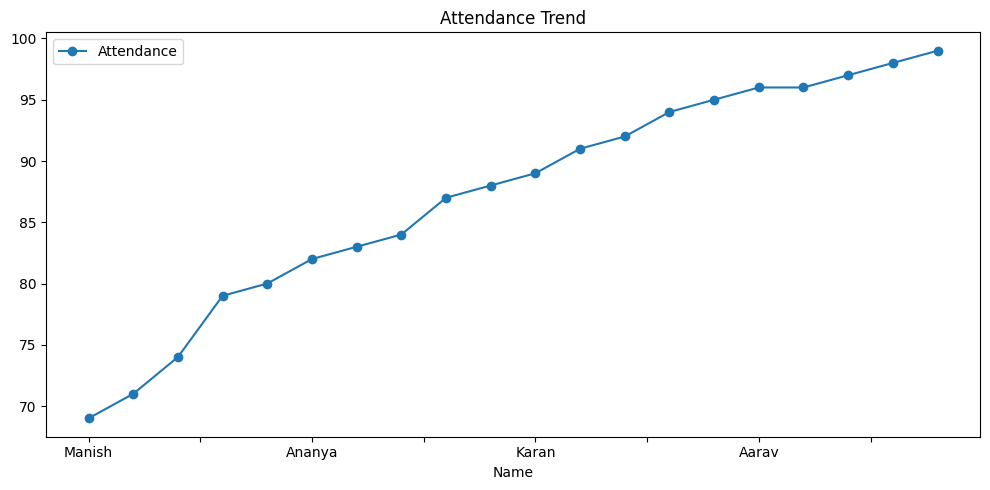

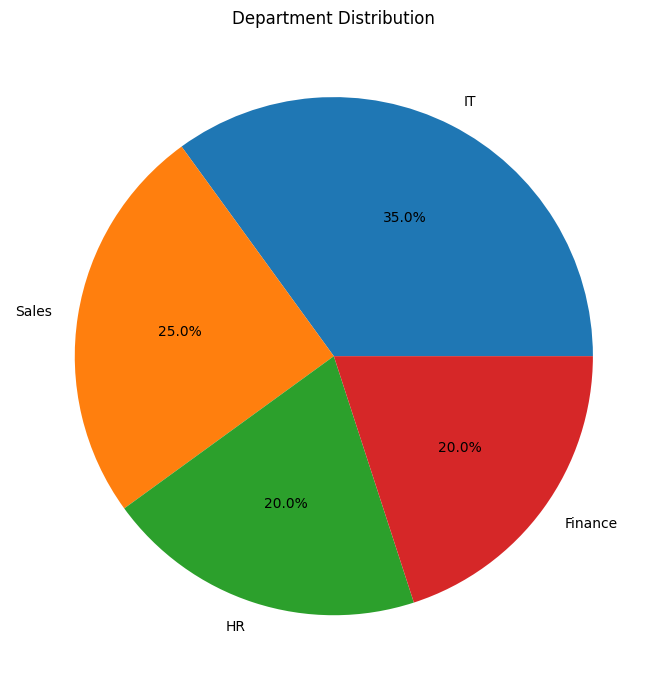

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("employee_data.csv").drop_duplicates()
df = df.dropna()
df["Performance"] = pd.to_numeric(df["Performance"])
df["Attendance"] = pd.to_numeric(df["Attendance"])

avg = df.groupby("Department")["Performance"].mean().sort_values(ascending=False)
top10 = df.sort_values("Performance", ascending=False).head(10)
low = df[df["Attendance"] < 75]

print("\nDEPARTMENT AVERAGE PERFORMANCE\n", avg)
print("\nTOP 10 PERFORMERS\n", top10[["Name","Department","Performance"]])
print("\nATTENDANCE BELOW 75%\n", low[["Name","Department","Attendance"]])

top10.plot(x="Name", y="Performance", kind="bar", figsize=(10,5), title="Performance Comparison")
plt.tight_layout(); plt.savefig("performance_comparison.png"); plt.show()

df.sort_values("Attendance").plot(x="Name", y="Attendance", kind="line", marker="o", figsize=(10,5), title="Attendance Trend")
plt.tight_layout(); plt.savefig("attendance_trend.png"); plt.show()

df["Department"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(7,7), title="Department Distribution")
plt.ylabel(""); plt.tight_layout(); plt.savefig("department_distribution.png"); plt.show()

df.to_csv("final_employee_report.csv", index=False)
top10.to_csv("top_10_performers.csv", index=False)
low.to_csv("low_attendance_employees.csv", index=False)